# 05.05 — Error and Cohort Analysis

## Purpose

Understand where the first model succeeds and fails using only supported history,
cold-start, genre-support, and test-time cohorts. MovieLens contains no defensible
demographic basis for interpretation here, so none is inferred.

## Setup

In [1]:
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CURRENT_PATH = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT_PATH, *CURRENT_PATH.parents)
     if (path / "README.md").is_file() and (path / ".git").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the movie_rating_predictor repository root")

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "rating_features_v1.parquet"
FEATURE_METADATA_PATH = PROJECT_ROOT / "data" / "features" / "rating_features_v1.metadata.json"
RATINGS_PATH = PROJECT_ROOT / "data" / "processed" / "ratings.parquet"
MODELS_DIR = PROJECT_ROOT / "models"

FEATURE_COLUMNS = [
    "global_rating_count",
    "global_mean_rating",
    "user_rating_count",
    "user_mean_rating",
    "user_rating_std_pop",
    "user_seconds_since_last_rating",
    "movie_rating_count",
    "movie_mean_rating",
    "movie_rating_std_pop",
    "movie_rating_count_30d",
    "user_target_genre_rating_count",
    "user_target_genre_mean_rating",
    "user_target_genre_mean_delta",
    "movie_genre_count",
    "movie_release_year",
    "movie_release_year_missing",
    "movie_age_years",
]

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Random seed:", RANDOM_SEED)
print("Feature count:", len(FEATURE_COLUMNS))
print("Features:", FEATURE_COLUMNS)


TRAIN_END = pd.Timestamp("2012-01-01")
VALIDATION_END = pd.Timestamp("2014-01-01")

SPLIT_DEFINITIONS = {
    "train": {"start": None, "end": TRAIN_END},
    "validation": {"start": TRAIN_END, "end": VALIDATION_END},
    "test": {"start": VALIDATION_END, "end": None},
}

def split_mask(timestamp: pd.Series, split_name: str) -> np.ndarray:
    bounds = SPLIT_DEFINITIONS[split_name]
    mask = np.ones(len(timestamp), dtype=bool)
    if bounds["start"] is not None:
        mask &= timestamp.to_numpy() >= bounds["start"].to_datetime64()
    if bounds["end"] is not None:
        mask &= timestamp.to_numpy() < bounds["end"].to_datetime64()
    return mask

Python: 3.14.6
pandas: 3.0.5
NumPy: 2.5.3
Random seed: 42
Feature count: 17
Features: ['global_rating_count', 'global_mean_rating', 'user_rating_count', 'user_mean_rating', 'user_rating_std_pop', 'user_seconds_since_last_rating', 'movie_rating_count', 'movie_mean_rating', 'movie_rating_std_pop', 'movie_rating_count_30d', 'user_target_genre_rating_count', 'user_target_genre_mean_rating', 'user_target_genre_mean_delta', 'movie_genre_count', 'movie_release_year', 'movie_release_year_missing', 'movie_age_years']


In [2]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from xgboost import XGBClassifier

print("XGBoost:", xgb.__version__)
rating_values = pd.read_parquet(RATINGS_PATH, columns=["rating"])["rating"].to_numpy(dtype=np.float32, copy=False)

def load_split(split_name: str, extra_columns=()):
    """Load one half-open temporal partition and attach labels by event identity."""
    bounds = SPLIT_DEFINITIONS[split_name]
    filters = []
    if bounds["start"] is not None:
        filters.append(("timestamp", ">=", bounds["start"]))
    if bounds["end"] is not None:
        filters.append(("timestamp", "<", bounds["end"]))

    columns = list(dict.fromkeys(["ratingEventId", "timestamp", *FEATURE_COLUMNS, *extra_columns]))
    frame = pd.read_parquet(FEATURE_PATH, columns=columns, filters=filters or None)
    if bounds["start"] is not None:
        frame = frame.loc[frame["timestamp"] >= bounds["start"]]
    if bounds["end"] is not None:
        frame = frame.loc[frame["timestamp"] < bounds["end"]]

    event_ids = frame["ratingEventId"].to_numpy(dtype=np.uint64, copy=False)
    if event_ids.min() < 1 or event_ids.max() > len(rating_values):
        raise AssertionError("ratingEventId is outside the canonical ratings row range")
    y = (rating_values[event_ids - 1] >= 4.0).astype(np.int8)
    return frame.reset_index(drop=True), y

def as_float32_matrix(frame: pd.DataFrame) -> np.ndarray:
    """Create the single compact dense matrix handed to XGBoost."""
    return frame.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=True)

XGBoost: 3.4.1


## Load and score untouched test events

In [3]:
model = XGBClassifier()
model.load_model(MODELS_DIR / "xgboost_baseline_v1.json")
test_frame, test_y = load_split("test")
X_test = as_float32_matrix(test_frame)
test_probability = model.predict_proba(X_test)[:, 1]
del X_test

analysis = test_frame[[
    "timestamp", "user_rating_count", "movie_rating_count", "user_target_genre_rating_count"
]].copy()
analysis["highRating"] = test_y
analysis["probability"] = test_probability
print("Test rows:", f"{len(analysis):,}")
print("Test prevalence:", analysis["highRating"].mean())

Test rows: 846,774
Test prevalence: 0.5017277337282439


## Cohort metric helper

ROC-AUC is reported only when both classes exist. All other requested statistics are
calculated for every nonempty cohort.

In [4]:
def cohort_metrics(frame: pd.DataFrame, cohort_column: str) -> pd.DataFrame:
    rows = []
    for cohort, group in frame.groupby(cohort_column, observed=True, sort=False):
        y_group = group["highRating"].to_numpy()
        p_group = group["probability"].to_numpy()
        rows.append({
            "Cohort": cohort,
            "Rows": len(group),
            "Prevalence": y_group.mean(),
            "ROC-AUC": roc_auc_score(y_group, p_group) if np.unique(y_group).size == 2 else np.nan,
            "PR-AUC": average_precision_score(y_group, p_group),
            "Log Loss": log_loss(y_group, p_group, labels=[0, 1]),
            "Average Prediction": p_group.mean(),
        })
    return pd.DataFrame(rows).set_index("Cohort")

## User-history maturity

In [5]:
analysis["user_maturity"] = pd.cut(
    analysis["user_rating_count"],
    bins=[-1, 0, 9, 99, np.inf],
    labels=["new (0)", "low (1-9)", "medium (10-99)", "high (100+)"],
)
user_results = cohort_metrics(analysis, "user_maturity")
display(user_results)

,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Average Prediction
Cohort,,,,,,
high (100+),493433,0.421765,0.797647,0.729724,0.535840,0.437238
medium (10-99),298589,0.628198,0.758359,0.825599,0.562699,0.678441
new (0),5477,0.572028,0.777149,0.800531,0.567481,0.517468
low (1-9),49275,0.528280,0.753927,0.762349,0.595668,0.551459


## Movie-history maturity

In [6]:
analysis["movie_maturity"] = pd.cut(
    analysis["movie_rating_count"],
    bins=[-1, 0, 19, 199, np.inf],
    labels=["new (0)", "low (1-19)", "medium (20-199)", "high (200+)"],
)
movie_results = cohort_metrics(analysis, "movie_maturity")
display(movie_results)

,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Average Prediction
Cohort,,,,,,
high (200+),756792,0.516731,0.791319,0.785521,0.552894,0.546500
medium (20-199),61759,0.396379,0.811327,0.728932,0.514412,0.402754
low (1-19),23489,0.346758,0.777822,0.639606,0.530152,0.359348
new (0),4734,0.246515,0.778900,0.526502,0.470645,0.301869


## Cold-start combinations

Cold means the strict-prior support count is zero at the prediction event.

In [7]:
cold_user = analysis["user_rating_count"].eq(0)
cold_movie = analysis["movie_rating_count"].eq(0)
analysis["cold_start"] = np.select(
    [cold_user & cold_movie, cold_user, cold_movie],
    ["both cold", "cold user only", "cold movie only"],
    default="established user/movie",
)
cold_start_results = cohort_metrics(analysis, "cold_start")
display(cold_start_results)

/Users/angel/Documents/movie_rating_predictor/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Average Prediction
Cohort,,,,,,
established user/movie,836567,0.502709,0.795013,0.780365,0.549319,0.530822
cold user only,5473,0.572447,0.777109,0.800658,0.567541,0.517565
cold movie only,4730,0.246723,0.779071,0.526756,0.470632,0.301799
both cold,4,0.000000,NaN,0.000000,0.485847,0.384769


## Target-genre support maturity

In [8]:
analysis["genre_support"] = pd.cut(
    analysis["user_target_genre_rating_count"],
    bins=[-1, 0, 9, 99, np.inf],
    labels=["none (0)", "low (1-9)", "medium (10-99)", "high (100+)"],
)
genre_results = cohort_metrics(analysis, "genre_support")
display(genre_results)

,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Average Prediction
Cohort,,,,,,
medium (10-99),326380,0.605935,0.767099,0.818984,0.562277,0.653007
high (100+),431971,0.412590,0.799333,0.724848,0.531936,0.426356
low (1-9),76040,0.555418,0.762063,0.785712,0.582073,0.585795
none (0),12383,0.534927,0.752265,0.748783,0.591043,0.523632


## Test-time drift by quarter

,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Average Prediction
Cohort,,,,,,
2014Q1,134320,0.530286,0.799062,0.806361,0.539369,0.536943
2014Q2,117973,0.512236,0.795273,0.792374,0.546649,0.519054
2014Q3,112771,0.529693,0.792152,0.797984,0.548524,0.539344
2014Q4,197824,0.500268,0.793877,0.778839,0.552977,0.539829
2015Q1,283886,0.473757,0.796982,0.760540,0.551943,0.519081


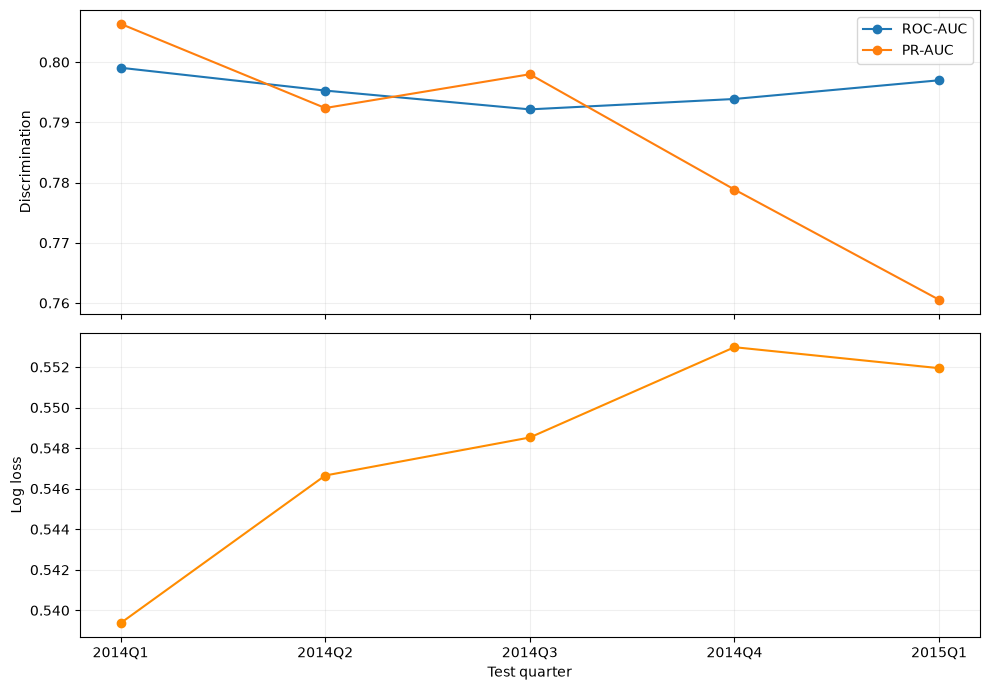

In [9]:
analysis["test_quarter"] = analysis["timestamp"].dt.to_period("Q").astype(str)
time_results = cohort_metrics(analysis, "test_quarter")
display(time_results)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(time_results.index, time_results["ROC-AUC"], marker="o", label="ROC-AUC")
axes[0].plot(time_results.index, time_results["PR-AUC"], marker="o", label="PR-AUC")
axes[0].legend()
axes[0].set_ylabel("Discrimination")
axes[1].plot(time_results.index, time_results["Log Loss"], marker="o", color="darkorange")
axes[1].set_ylabel("Log loss")
axes[1].set_xlabel("Test quarter")
for ax in axes:
    ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

## Persist cohort summaries

In [10]:
def records(frame):
    return json.loads(frame.reset_index().to_json(orient="records"))

error_analysis_payload = {
    "user_maturity": records(user_results),
    "movie_maturity": records(movie_results),
    "cold_start": records(cold_start_results),
    "genre_support": records(genre_results),
    "test_quarter": records(time_results),
}
output_path = MODELS_DIR / "xgboost_baseline_v1.error_analysis.json"
output_path.write_text(json.dumps(error_analysis_payload, indent=2) + "\n")
print("Saved:", output_path.relative_to(PROJECT_ROOT))

Saved: models/xgboost_baseline_v1.error_analysis.json
